/tmp/ipykernel_1647/667167379.py:57: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/667167379.py:57: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/667167379.py:57: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/667167379.py:57: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/667167379.py:57: UserWarning: Glyph 3606 (\N{THAI CHARACTER THO THUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/667167379.py:57: UserWarning: Glyph 3638 (\N{THAI CHARACTER SARA UE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/667167379.py:57: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  pl

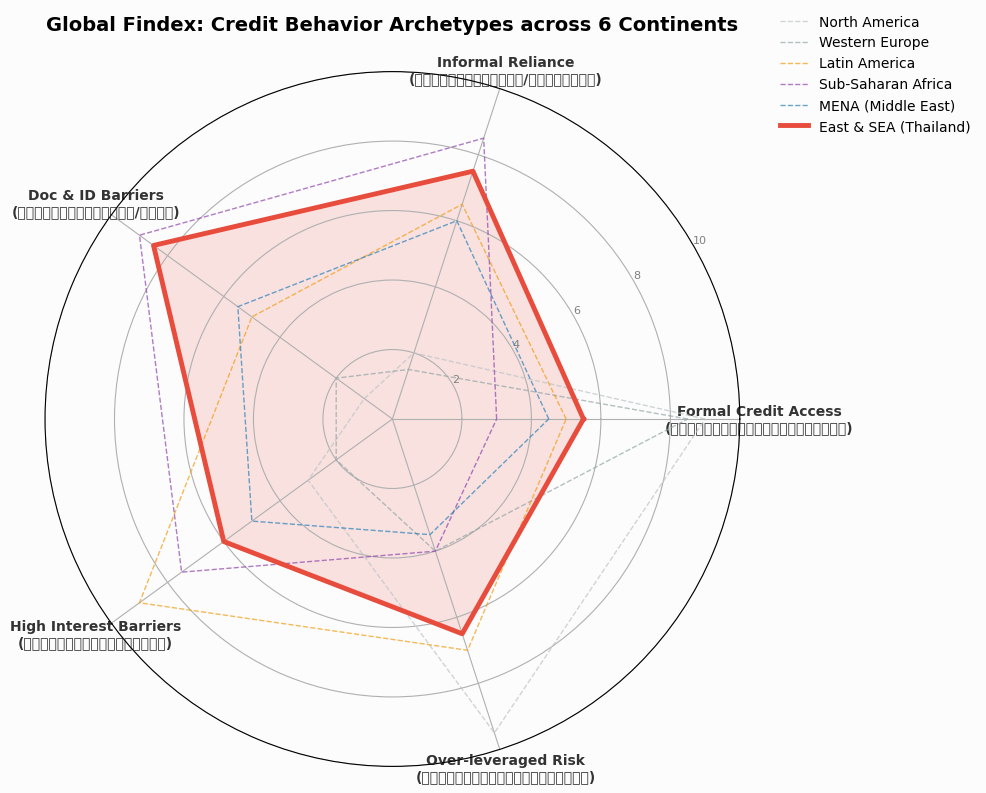

/tmp/ipykernel_1647/667167379.py:97: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/667167379.py:97: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/667167379.py:97: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/667167379.py:97: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/667167379.py:97: UserWarning: Glyph 3624 (\N{THAI CHARACTER SO SALA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/667167379.py:97: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/667167379.py:97: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  pl

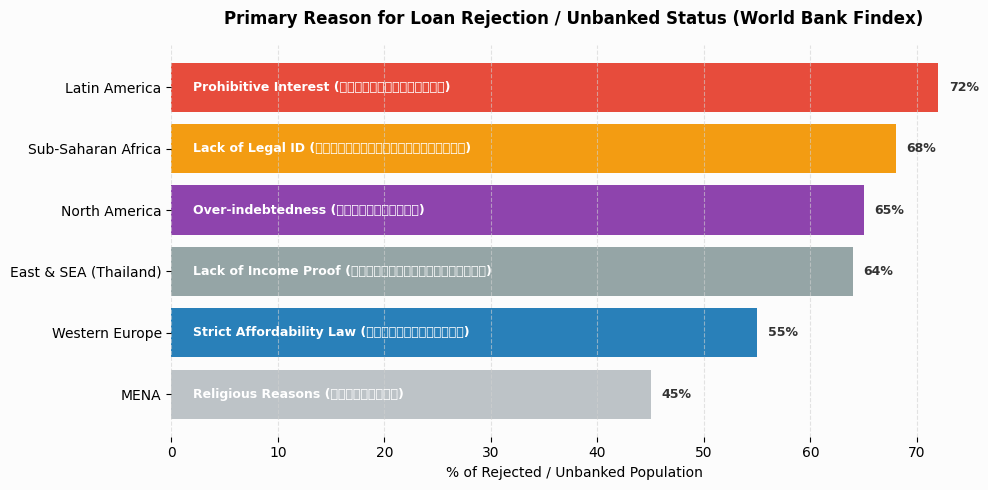

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. เตรียมข้อมูล (Synthesized aggregated Findex Data - Scale 1 to 10)
categories = [
    'Formal Credit Access\n(เข้าถึงสินเชื่อในระบบ)',
    'Informal Reliance\n(พึ่งพานอกระบบ/ครอบครัว)',
    'Doc & ID Barriers\n(ติดปัญหาเอกสาร/สลิป)',
    'High Interest Barriers\n(สู้ดอกเบี้ยไม่ไหว)',
    'Over-leveraged Risk\n(ความเสี่ยงหนี้ล้นตัว)'
]

data = {
    'North America':        [9.0, 2.0, 1.0, 3.0, 9.5],
    'Western Europe':       [8.5, 1.5, 2.0, 2.0, 4.0],
    'Latin America':        [5.0, 6.5, 5.0, 9.0, 7.0],
    'Sub-Saharan Africa':   [3.0, 8.5, 9.0, 7.5, 4.0],
    'MENA (Middle East)':   [4.5, 6.0, 5.5, 5.0, 3.5],
    'East & SEA (Thailand)':[5.5, 7.5, 8.5, 6.0, 6.5] # พระเอกของเรา
}

# ---------------------------------------------------------
# VISUALIZATION 1: กราฟใยแมงมุม (Radar Chart)
# ---------------------------------------------------------
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # ปิดวงกลม

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#fcfcfc')
ax.set_facecolor('#fcfcfc')

# ตั้งค่าแกนหมุน
plt.xticks(angles[:-1], categories, color='#333333', size=10, fontweight='bold')
ax.set_rlabel_position(30)
plt.yticks([2, 4, 6, 8, 10], ["2", "4", "6", "8", "10"], color="grey", size=8)
plt.ylim(0, 10)

# พล็อตทีละทวีป
colors = {'North America': '#bdc3c7', 'Western Europe': '#95a5a6',
          'Latin America': '#f39c12', 'Sub-Saharan Africa': '#8e44ad',
          'MENA (Middle East)': '#2980b9', 'East & SEA (Thailand)': '#e74c3c'}

for region, values in data.items():
    val_closed = values + values[:1]
    if region == 'East & SEA (Thailand)':
        # เน้นทวีปของเราให้เด่นพุ่งออกมา (สีแดงเส้นหนา)
        ax.plot(angles, val_closed, linewidth=3.5, linestyle='solid', label=region, color=colors[region])
        ax.fill(angles, val_closed, colors[region], alpha=0.15)
    else:
        ax.plot(angles, val_closed, linewidth=1.0, linestyle='dashed', label=region, color=colors[region], alpha=0.7)

plt.title("Global Findex: Credit Behavior Archetypes across 6 Continents", size=14, fontweight='bold', pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), frameon=False)
plt.tight_layout()

plt.savefig('global_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# VISUALIZATION 2: กราฟแท่ง Top Rejection Reasons
# ---------------------------------------------------------
rejection_data = pd.DataFrame({
    'Region': ['North America', 'Western Europe', 'Latin America', 'Sub-Saharan Africa', 'MENA', 'East & SEA (Thailand)'],
    'Primary_Reason': ['Over-indebtedness (หนี้เดิมล้น)', 'Strict Affordability Law (ติดกฎเกณฑ์รัฐ)',
                       'Prohibitive Interest (ดอกเบี้ยมหาโหด)', 'Lack of Legal ID (ไม่มีตัวตนทางดิจิทัล)',
                       'Religious Reasons (หลักศาสนา)', 'Lack of Income Proof (ไม่มีสลิปเงินเดือน)'],
    'Impact_Percentage': [65, 55, 72, 68, 45, 64]
})

rejection_data = rejection_data.sort_values(by='Impact_Percentage', ascending=True)

plt.figure(figsize=(10, 5), facecolor='#fcfcfc')
ax2 = plt.axes()
ax2.set_facecolor('#fcfcfc')

bars = plt.barh(rejection_data['Region'], rejection_data['Impact_Percentage'],
                color=['#bdc3c7', '#2980b9', '#95a5a6', '#8e44ad', '#f39c12', '#e74c3c']) # แดงที่ไทย

plt.title("Primary Reason for Loan Rejection / Unbanked Status (World Bank Findex)", size=12, fontweight='bold', pad=15)
plt.xlabel("% of Rejected / Unbanked Population")

# ใส่ตัวเลขกำกับท้ายแท่ง
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{int(width)}%',
             va='center', ha='left', fontweight='bold', color='#333333', size=9)

# Label ชี้แจงเหตุผล
for i, reason in enumerate(rejection_data['Primary_Reason']):
    plt.text(2, i, reason, va='center', color='white', fontweight='bold', size=9)

sns.despine(left=True, bottom=True)
ax2.xaxis.grid(True, linestyle='--', alpha=0.6, color='#d1d1d1')
plt.tight_layout()

plt.savefig('global_rejection_reasons.png', dpi=300, bbox_inches='tight')
plt.show()

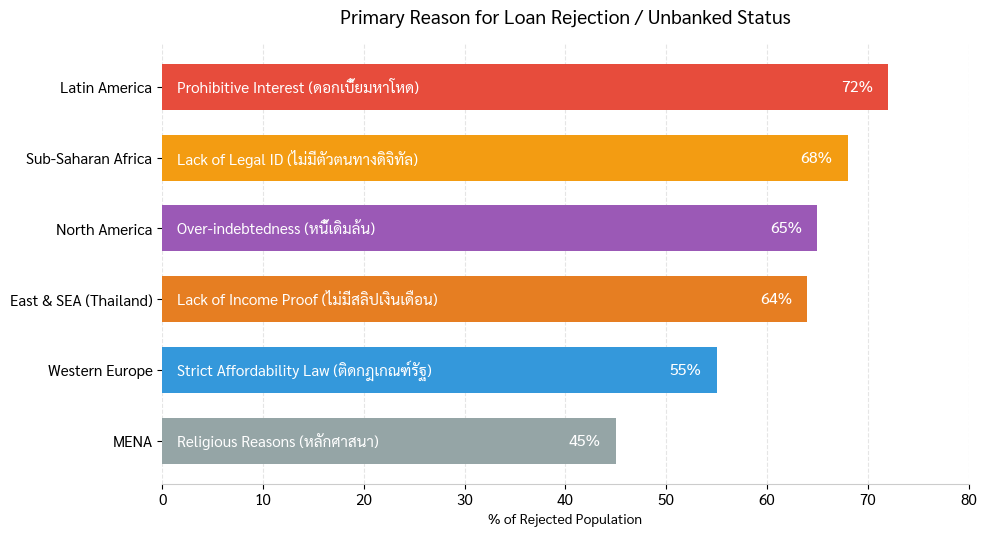

In [8]:
import urllib.request
from matplotlib import font_manager
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# 1. [ท่าโกง] เสกฟอนต์ TH Sarabun จาก Google เข้า Matplotlib ทันที
# ==========================================
font_url = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
urllib.request.urlretrieve(font_url, "Sarabun-Regular.ttf")

font_manager.fontManager.addfont("Sarabun-Regular.ttf")
plt.rcParams['font.family'] = 'Sarabun'
plt.rcParams['font.size'] = 11  # ปรับสเกลสระ-วรรณยุกต์ไทยให้พอดี

# ==========================================
# 2. ข้อมูลชุดเดิม (คราวนี้ภาษาไทยจะอ่านออก 100%)
# ==========================================
df = pd.DataFrame(
    {
        'Region': [
            'North America',
            'Western Europe',
            'Latin America',
            'Sub-Saharan Africa',
            'MENA',
            'East & SEA (Thailand)',
        ],
        'Primary_Reason': [
            'Over-indebtedness (หนี้เดิมล้น)',
            'Strict Affordability Law (ติดกฎเกณฑ์รัฐ)',
            'Prohibitive Interest (ดอกเบี้ยมหาโหด)',
            'Lack of Legal ID (ไม่มีตัวตนทางดิจิทัล)',
            'Religious Reasons (หลักศาสนา)',
            'Lack of Income Proof (ไม่มีสลิปเงินเดือน)',
        ],
        'Impact': [65, 55, 72, 68, 45, 64],
    }
)

df = df.sort_values(by='Impact', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='#ffffff')
fig.patch.set_alpha(1.0)
ax.set_facecolor('#ffffff')

colors = ['#95a5a6', '#3498db', '#e67e22', '#9b59b6', '#f39c12', '#e74c3c']
bars = ax.barh(df['Region'], df['Impact'], color=colors, height=0.65)
ax.set_xlim(0, 80)

# 3. แปะข้อความลงแท่งกราฟ
for i in range(len(df)):
    val = df['Impact'].iloc[i]
    reason = df['Primary_Reason'].iloc[i]

    # ข้อความภาษาไทย (ชิดซ้าย) -> จะแสดงผลเป็นฟอนต์สารบรรณสวยงาม
    ax.text(
        1.5,
        i,
        reason,
        va='center',
        ha='left',
        fontsize=11,
        fontweight='bold',
        color='white',
    )
    # ตัวเลข % (ชิดขวา)
    ax.text(
        val - 1.5,
        i,
        f"{val}%",
        va='center',
        ha='right',
        fontsize=11.5,
        fontweight='heavy',
        color='white',
    )

ax.set_title(
    "Primary Reason for Loan Rejection / Unbanked Status",
    fontsize=14,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel("% of Rejected Population", fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('global_rejection_reasons_TH_fixed.png', dpi=300)
plt.show()

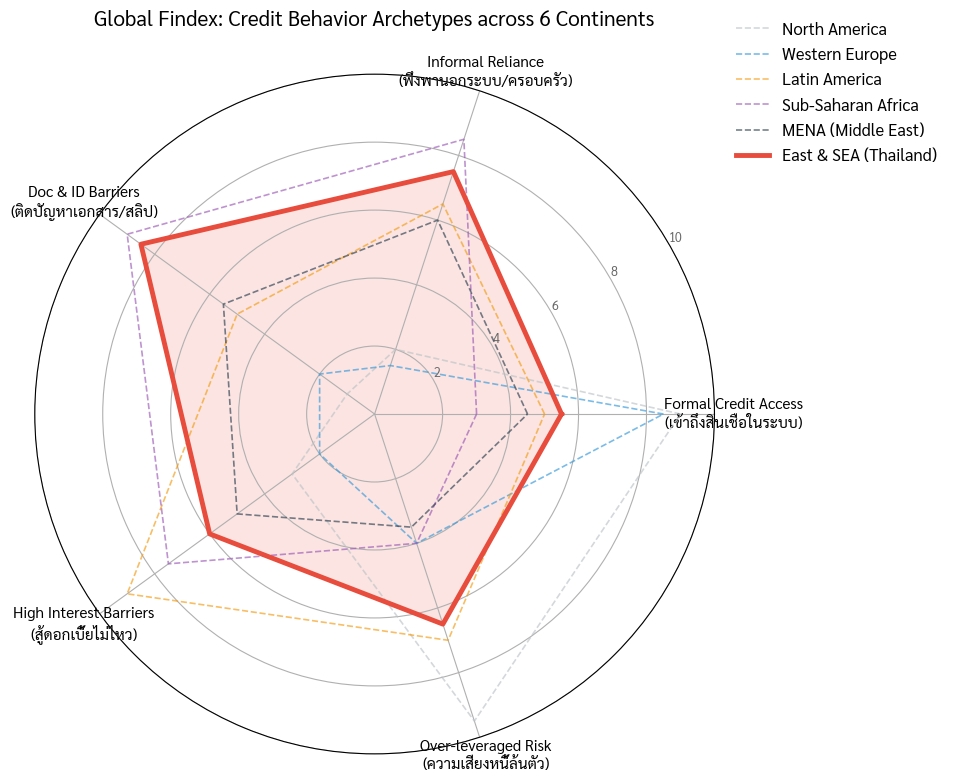

In [9]:
import urllib.request
from matplotlib import font_manager
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. [ท่าโกง] ดึงฟอนต์ TH Sarabun จาก Google Storage มาฝังใน Matplotlib
# ==========================================
font_url = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
urllib.request.urlretrieve(font_url, "Sarabun-Regular.ttf")

font_manager.fontManager.addfont("Sarabun-Regular.ttf")
plt.rcParams['font.family'] = 'Sarabun'
plt.rcParams['font.size'] = 12  # ปรับสเกลตัวอักษรไทยรอบวงกลมให้คมชัด

# ==========================================
# 2. ข้อมูล 5 แกน (พฤติกรรมทางการเงิน 6 ทวีป)
# ==========================================
categories = [
    'Formal Credit Access\n(เข้าถึงสินเชื่อในระบบ)',
    'Informal Reliance\n(พึ่งพานอกระบบ/ครอบครัว)',
    'Doc & ID Barriers\n(ติดปัญหาเอกสาร/สลิป)',
    'High Interest Barriers\n(สู้ดอกเบี้ยไม่ไหว)',
    'Over-leveraged Risk\n(ความเสี่ยงหนี้ล้นตัว)',
]

data = {
    'North America': [9.0, 2.0, 1.0, 3.0, 9.5],
    'Western Europe': [8.5, 1.5, 2.0, 2.0, 4.0],
    'Latin America': [5.0, 6.5, 5.0, 9.0, 7.0],
    'Sub-Saharan Africa': [3.0, 8.5, 9.0, 7.5, 4.0],
    'MENA (Middle East)': [4.5, 6.0, 5.5, 5.0, 3.5],
    'East & SEA (Thailand)': [5.5, 7.5, 8.5, 6.0, 6.5],  # พระเอกของเรา
}

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # ปิดวงกลม

# ==========================================
# 3. วาดกราฟ (ล็อก Canvas พื้นหลังขาวทึบ 100%)
# ==========================================
fig, ax = plt.subplots(
    figsize=(10, 8), subplot_kw=dict(polar=True), facecolor='white'
)
fig.patch.set_alpha(1.0)
ax.set_facecolor('white')
ax.patch.set_alpha(1.0)

# วาดป้ายกำกับ 5 แกนรอบวงกลม (บังคับสีดำสนิท)
plt.xticks(
    angles[:-1], categories, color='black', size=11, fontweight='heavy'
)

# ตั้งค่าสเกลใยแมงมุมชั้นใน
ax.set_rlabel_position(30)
plt.yticks(
    [2, 4, 6, 8, 10], ["2", "4", "6", "8", "10"], color="dimgray", size=9
)
plt.ylim(0, 10)

colors = {
    'North America': '#bdc3c7',
    'Western Europe': '#3498db',
    'Latin America': '#f39c12',
    'Sub-Saharan Africa': '#9b59b6',
    'MENA (Middle East)': '#2c3e50',
    'East & SEA (Thailand)': '#e74c3c',
}

for region, values in data.items():
    val_closed = values + values[:1]
    if region == 'East & SEA (Thailand)':
        # พล็อตเส้นประเทศไทย: สีแดงเด้งออกมา, หนาพิเศษ
        ax.plot(
            angles,
            val_closed,
            linewidth=3.5,
            linestyle='solid',
            label=region,
            color=colors[region],
        )
        ax.fill(angles, val_closed, colors[region], alpha=0.15)
    else:
        # ทวีปอื่นๆ: เส้นบาง, ประ, โปร่งแสง
        ax.plot(
            angles,
            val_closed,
            linewidth=1.2,
            linestyle='dashed',
            label=region,
            color=colors[region],
            alpha=0.65,
        )

plt.title(
    "Global Findex: Credit Behavior Archetypes across 6 Continents",
    size=15,
    fontweight='bold',
    pad=35,
    color='black',
)

# กล่อง Legend ชี้แจงสี (บังคับตัวหนังสือสีดำ)
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.35, 1.1),
    frameon=False,
    labelcolor='black',
)

plt.tight_layout()

# บังคับ Save โดยล็อกพารามิเตอร์ facecolor='white'
plt.savefig(
    'global_radar_chart_TH_fixed.png',
    dpi=300,
    facecolor='white',
    transparent=False,
)
plt.show()